In [1]:
from typing import List, Union, NoReturn, Callable
import functools
import logging
from pathlib import Path
from collections import namedtuple
from concurrent.futures import ProcessPoolExecutor
import os

import tqdm
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

import torch
from torch.utils.data import DataLoader, Dataset
from torch import nn
from esm import FastaBatchedDataset, pretrained

from sklearn.preprocessing import StandardScaler

In [2]:
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logging.debug("test")

In [3]:
DATA = Path("..") / "data"
SMILES = "compound_structures.canonical_smiles"
ACT = "activities.standard_value"

In [4]:
def extract_embeddings(
    model_name: str,
    fasta_file: Union[Path, str],
    output_dir: Union[Path, str],
    tokens_per_batch: int = 4096,
    seq_length: int = 5000,
    repr_layers: List[int] = [33],
):
    dataset = FastaBatchedDataset.from_file(fasta_file)
    filename = lambda uniprot_id: output_dir / f"{uniprot_id}.pt"
    data = [
        (label, seq)
        for label, seq in zip(dataset.sequence_labels, dataset.sequence_strs)
        if not filename(label).exists()
    ]
    dataset.sequence_labels = [label for label, _ in data]
    dataset.sequence_strs = [seq for _, seq in data]
    if len(data) == 0:
        return

    logger.info("Setting up ESM model")
    model, alphabet = pretrained.load_model_and_alphabet(model_name)
    model.eval()

    if torch.cuda.is_available():
        model = model.cuda()

    logger.info(f"Computing ESM embeddings for {len(data)} sequences")
    batches = dataset.get_batch_indices(tokens_per_batch, extra_toks_per_seq=1)

    data_loader = torch.utils.data.DataLoader(
        dataset,
        collate_fn=alphabet.get_batch_converter(seq_length),
        batch_sampler=batches,
    )

    output_dir.mkdir(parents=True, exist_ok=True)

    with torch.no_grad():
        for batch_idx, (labels, strs, toks) in tqdm.tqdm(
            enumerate(data_loader), total=len(batches)
        ):
            if torch.cuda.is_available():
                toks = toks.to(device="cuda", non_blocking=True)

            out = model(toks, repr_layers=repr_layers, return_contacts=False)

            logits = out["logits"].to(device="cpu")
            representations = {
                layer: t.to(device="cpu") for layer, t in out["representations"].items()
            }

            for i, label in enumerate(labels):
                entry_id = label.split()[0]
                truncate_len = min(seq_length, len(strs[i]))
                result = {"entry_id": entry_id}
                result["representation"] = {
                    layer: t[i, 1 : truncate_len + 1].mean(0).clone()
                    for layer, t in representations.items()
                }

                torch.save(result, filename(entry_id))

In [5]:
def load_kinodata(
    kinodata_path: Path = DATA / "raw" / "activities-chembl33_v0.5.csv",
    activity_types: List[str] = ["pIC50"],
) -> pd.DataFrame:
    logger.info(f"Loading kinodata activities from {kinodata_path}")
    data = pd.read_csv(kinodata_path, index_col=0)
    data = data[data["activities.standard_type"].isin(activity_types)]
    data = data[~data["compound_structures.canonical_smiles"].isna()]
    return data

In [6]:
kinodata = load_kinodata()

INFO:root:Loading kinodata activities from ../data/raw/activities-chembl33_v0.5.csv


In [7]:
class FingerprintFactory(Callable):
    def __init__(self, mfpgen=None):
        if mfpgen is None:
            self.mfpgen = rdFingerprintGenerator.GetMorganGenerator(
                radius=2, fpSize=2048
            )

    @functools.cache
    def __call__(self, smi: str) -> Union[str, NoReturn]:
        try:
            return torch.tensor(
                self.mfpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smi)),
                dtype=torch.float32,
            )
        except TypeError:
            logger.warning(f"No fp for SMILES={smi}")
            return None

In [8]:
fp_gen = FingerprintFactory()

In [9]:
class ActivityDataset(Dataset):
    def __init__(
        self,
        kinodata: pd.DataFrame,
        target: str = "activities.standard_value",
        keep_cols: List[str] = [],
        fp_gen: Union[FingerprintFactory, None] = None,
    ):
        super().__init__()
        if fp_gen is None:
            self.fp_gen = FingerprintFactory()
        else:
            self.fp_gen = fp_gen
        logger.info("Computing fingerprints")
        self.ligand_features = torch.stack(
            [
                self.fp_gen(smi)
                for smi in tqdm.tqdm(
                    kinodata["compound_structures.canonical_smiles"].values
                )
            ]
        )
        self._compute_protein_features(kinodata)
        self.labels = torch.tensor(kinodata[target].values, dtype=torch.float32)
        self.info = torch.tensor(kinodata[keep_cols].values)

    def _compute_protein_features(self, data: pd.DataFrame):
        logger.info("Computing ESM embeddings")

        done = []
        fasta_file = DATA / "data.fasta"
        with open(fasta_file, "w") as f:
            for i, row in data.iterrows():
                uniprot = row["UniprotID"]
                if uniprot in done:
                    continue
                f.write(f">{uniprot}\n{row['component_sequences.sequence']}\n")
                done.append(uniprot)

        model_name = "esm2_t33_650M_UR50D"
        output_dir = DATA / model_name
        output_dir.mkdir(exist_ok=True)
        extract_embeddings(model_name, fasta_file, output_dir)

        @functools.cache
        def load_esm(uniprot_id: str) -> torch.Tensor:
            return torch.load(output_dir / f"{uniprot_id}.pt", weights_only=False)[
                "representation"
            ][33]

        self.protein_features = torch.stack(
            [load_esm(uniprot_id) for uniprot_id in data["UniprotID"]]
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.protein_features[idx],
            self.ligand_features[idx],
            self.labels[idx],
            self.info[idx],
        )

In [10]:
class CombinedModel(nn.Module):
    def __init__(self, protein_input_size, ligand_input_size, embedding_size):
        super(CombinedModel, self).__init__()

        # Protein sequence transformer
        self.protein_mlp = nn.Sequential(
            nn.Linear(protein_input_size, 512),
            nn.SiLU(),
            nn.Linear(512, 512),
            nn.SiLU(),
            nn.Linear(512, embedding_size),
        )

        # Ligand MLP
        self.ligand_mlp = nn.Sequential(
            nn.Linear(ligand_input_size, 512),
            nn.SiLU(),
            nn.Linear(512, 512),
            nn.SiLU(),
            nn.Linear(512, embedding_size),
        )

        # Combined MLP
        self.combined_mlp = nn.Sequential(
            nn.Linear(embedding_size * 2, 512),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 128),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1),
        )

    def forward(self, protein, ligand):
        protein_embedding = self.protein_mlp(protein)

        ligand_embedding = self.ligand_mlp(ligand)

        combined_embedding = torch.cat([protein_embedding, ligand_embedding], dim=1)
        output = self.combined_mlp(combined_embedding)
        return output


def val_model(model, loader, criterion=nn.L1Loss()):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        all_preds = list()
        all_labels = list()
        all_info = list()
        for protein_features, ligand_features, labels, info in loader:
            protein_features, ligand_features, labels = (
                protein_features.to(device),
                ligand_features.to(device),
                labels.to(device),
            )
            predictions = model(protein_features, ligand_features).squeeze()
            loss = criterion(predictions, labels)
            val_loss += loss.item()

            all_preds.extend(list(predictions.cpu().numpy().flatten()))
            all_labels.extend(list(labels.cpu().numpy().flatten()))
            all_info.extend(list(info.cpu().numpy().flatten()))

    val_data = pd.DataFrame(
        {
            "prediction": all_preds,
            "label": all_labels,
            "assay": all_info,
        }
    )
    mean_rank_corr = 0
    for assay_id, group in val_data.groupby("assay"):
        if group["label"].nunique() == 1 or group["prediction"].nunique() == 1:
            continue
        rank_corr, _ = spearmanr(group["prediction"], group["label"])
        if np.isnan(rank_corr):
            continue
        mean_rank_corr += len(group) * rank_corr / len(val_data)

    val_loss /= len(val_loader)

    return val_loss, mean_rank_corr


def train_model(model, loader, optimizer, criterion=nn.MSELoss()):
    model.train()
    train_loss = 0
    for protein_features, ligand_features, labels, _ in tqdm.tqdm(loader):
        protein_features, ligand_features, labels = (
            protein_features.to(device),
            ligand_features.to(device),
            labels.to(device),
        )

        optimizer.zero_grad()
        predictions = model(protein_features, ligand_features).squeeze()
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    train_loss /= len(loader)
    return train_loss

In [11]:
kinodata["assay_id"] = kinodata["assays.chembl_id"].str[6:].astype(int)

In [12]:
def split_kfold_by(
    kinodata: pd.DataFrame, k: int, column: str, seed: int = 0
) -> np.ndarray:
    """Return the k-fold partitioning of `kinodata[column]` in shape `(k, -1)`."""
    values = kinodata[column].unique()
    missing_modk = k - len(values) % k
    values = np.concatenate((values, [-1] * missing_modk))
    np.random.seed(seed)
    np.random.shuffle(values)
    return values.reshape(k, -1)

In [13]:
col = "assay_id"
partition = split_kfold_by(kinodata, column=col, k=5)

In [14]:
index = 0

train = ~kinodata[col].isin(partition[index])
val = kinodata[col].isin(partition[index])

scaler = StandardScaler()
tgt_name = "scaled_ic50"
kinodata.loc[train, tgt_name] = scaler.fit_transform(
    kinodata.loc[train, "activities.standard_value"].values.reshape(-1, 1)
)
kinodata.loc[val, tgt_name] = scaler.transform(
    kinodata.loc[val, "activities.standard_value"].values.reshape(-1, 1)
)

In [15]:
train_dataset = ActivityDataset(
    kinodata[train], fp_gen=fp_gen, target=tgt_name, keep_cols=["assay_id"]
)
val_dataset = ActivityDataset(
    kinodata[val], fp_gen=fp_gen, target=tgt_name, keep_cols=["assay_id"]
)

INFO:root:Computing fingerprints
100%|█████████████████████████████████| 145972/145972 [00:44<00:00, 3306.64it/s]
INFO:root:Computing ESM embeddings
INFO:root:Computing fingerprints
100%|███████████████████████████████████| 34010/34010 [00:08<00:00, 3802.80it/s]
INFO:root:Computing ESM embeddings


In [16]:
protein_input_size = 1280
ligand_input_size = 2048
embedding_size = 256

In [17]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CombinedModel(protein_input_size, ligand_input_size, embedding_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(30):
    train_loss = train_model(model, train_loader, optimizer)
    val_loss, mean_rank_corr = val_model(model, val_loader)
    logger.info(
        f"Epoch {epoch + 1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Mean Rank Correlation = {mean_rank_corr:.4f}"
    )

100%|█████████████████████████████████████████| 571/571 [00:17<00:00, 33.15it/s]
INFO:root:Epoch 1: Train Loss = 0.6563, Val Loss = 0.6922, Mean Rank Correlation = 0.1447
100%|█████████████████████████████████████████| 571/571 [00:17<00:00, 33.39it/s]
INFO:root:Epoch 2: Train Loss = 0.5598, Val Loss = 0.6798, Mean Rank Correlation = 0.1603
100%|█████████████████████████████████████████| 571/571 [00:16<00:00, 33.64it/s]
INFO:root:Epoch 3: Train Loss = 0.4748, Val Loss = 0.6663, Mean Rank Correlation = 0.1672
100%|█████████████████████████████████████████| 571/571 [00:17<00:00, 33.05it/s]
INFO:root:Epoch 4: Train Loss = 0.3983, Val Loss = 0.6489, Mean Rank Correlation = 0.1910
100%|█████████████████████████████████████████| 571/571 [00:17<00:00, 32.44it/s]
INFO:root:Epoch 5: Train Loss = 0.3395, Val Loss = 0.6707, Mean Rank Correlation = 0.2088
100%|█████████████████████████████████████████| 571/571 [00:20<00:00, 27.28it/s]
INFO:root:Epoch 6: Train Loss = 0.2954, Val Loss = 0.6355, Mean 

In [18]:
HodgeRank = namedtuple("HodgeRank", "UniprotID smiles hodge_score".split())

In [19]:
def hodge_rank(y_bar, w, diag_stab=0.0):
    laplacian = -w
    laplacian[np.diag_indices_from(w)] = w.sum(0) + diag_stab
    y_bar = np.nan_to_num(y_bar)  # nan to zero
    divergence = (w * y_bar).sum(0)
    try:
        scores = -np.linalg.pinv(laplacian) @ divergence
        return scores
    except np.linalg.LinAlgError:
        logger.warning("Unstable SVD")
        return hodge_rank(y_bar, w, diag_stab=diag_stab + 1e-5)

In [20]:
all_scores = list()


def process_target_group_from_file(input_file):
    group_data = pd.read_csv(input_file)
    target = group_data["UniprotID"].iloc[0]
    cmpds = list(group_data[SMILES].unique())
    dim = len(cmpds)
    y_bar = np.zeros((dim, dim))
    weights = np.zeros((dim, dim))

    for assay_id, subset in group_data.groupby("assay_id"):
        for i in range(len(subset)):
            for j in range(i):
                pref = subset.iloc[i][ACT] - subset.iloc[j][ACT]
                cmpd_i, cmpd_j = subset.iloc[i][SMILES], subset.iloc[j][SMILES]
                c_i, c_j = cmpds.index(cmpd_i), cmpds.index(cmpd_j)
                y_bar[c_i, c_j] += pref
                y_bar[c_j, c_i] -= pref
                weights[c_i, c_j] += 1

    weights[np.diag_indices_from(weights)] = 0
    weights += weights.T

    scores = hodge_rank(y_bar, weights)

    return [HodgeRank(target, cmpd, float(score)) for cmpd, score in zip(cmpds, scores)]


def parallel_hodge_rank(kinodata, train):
    global all_scores
    all_scores = list()

    groups = list(kinodata[train].groupby("UniprotID"))

    os.makedirs("group_data", exist_ok=True)

    group_files = []
    for i, (target, tgt_data) in enumerate(groups):
        file_path = f"group_data/group_{i}.csv"
        tgt_data.to_csv(file_path, index=False)
        group_files.append(file_path)

    with ProcessPoolExecutor() as executor:
        results = list(
            tqdm.tqdm(
                executor.map(process_target_group_from_file, group_files),
                total=len(group_files),
            )
        )

    for result in results:
        all_scores.extend(result)


# Run the function
parallel_hodge_rank(kinodata, train)

100%|█████████████████████████████████████████| 398/398 [34:54<00:00,  5.26s/it]


In [21]:
hodge_df = pd.DataFrame(all_scores)
hodge_df = hodge_df.rename(columns={"smiles": "compound_structures.canonical_smiles"})

In [22]:
hodge_kd = kinodata.merge(
    hodge_df, on=["compound_structures.canonical_smiles", "UniprotID"], how="inner"
)

Text(0.5, 1.0, 'P42336')

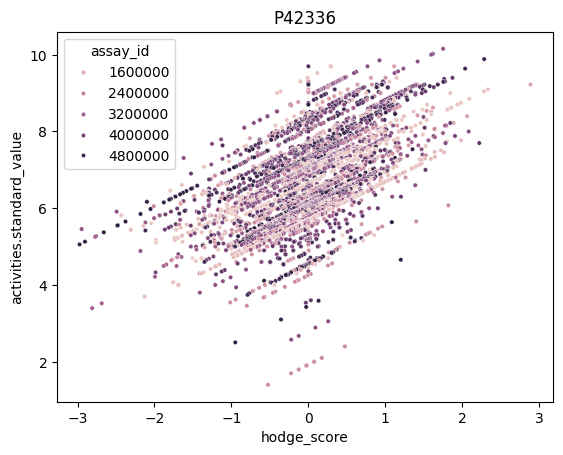

In [37]:
prot = hodge_kd.UniprotID.sample(1).values[0]
sns.scatterplot(
    hodge_kd[hodge_kd.UniprotID == prot], x="hodge_score", y=ACT, hue="assay_id", s=10
).set_title(prot)

In [25]:
train_dataset = ActivityDataset(
    hodge_kd, fp_gen=fp_gen, target="hodge_score", keep_cols=["assay_id"]
)
val_dataset = ActivityDataset(
    kinodata[val], fp_gen=fp_gen, target=tgt_name, keep_cols=["assay_id"]
)

INFO:root:Computing fingerprints
100%|██████████████████████████████| 146388/146388 [00:00<00:00, 1787531.95it/s]
INFO:root:Computing ESM embeddings
INFO:root:Computing fingerprints
100%|████████████████████████████████| 34010/34010 [00:00<00:00, 1568459.77it/s]
INFO:root:Computing ESM embeddings


In [26]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CombinedModel(protein_input_size, ligand_input_size, embedding_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(30):
    train_loss = train_model(model, train_loader, optimizer)
    val_loss, mean_rank_corr = val_model(model, val_loader)
    logger.info(
        f"Epoch {epoch + 1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Mean Rank Correlation = {mean_rank_corr:.4f}"
    )

100%|█████████████████████████████████████████| 572/572 [00:14<00:00, 39.61it/s]
INFO:root:Epoch 1: Train Loss = 0.5385, Val Loss = 0.7845, Mean Rank Correlation = 0.1475
100%|█████████████████████████████████████████| 572/572 [00:14<00:00, 39.00it/s]
INFO:root:Epoch 2: Train Loss = 0.5029, Val Loss = 0.7806, Mean Rank Correlation = 0.1644
100%|█████████████████████████████████████████| 572/572 [00:14<00:00, 38.34it/s]
INFO:root:Epoch 3: Train Loss = 0.4735, Val Loss = 0.7817, Mean Rank Correlation = 0.1829
100%|█████████████████████████████████████████| 572/572 [00:14<00:00, 38.51it/s]
INFO:root:Epoch 4: Train Loss = 0.4346, Val Loss = 0.7846, Mean Rank Correlation = 0.2133
100%|█████████████████████████████████████████| 572/572 [00:15<00:00, 37.86it/s]
INFO:root:Epoch 5: Train Loss = 0.3867, Val Loss = 0.7791, Mean Rank Correlation = 0.2441
100%|█████████████████████████████████████████| 572/572 [00:14<00:00, 38.31it/s]
INFO:root:Epoch 6: Train Loss = 0.3429, Val Loss = 0.7899, Mean 